---
title: "Smoothing of credit card operations using time series techniques"
date: "2025-01-30"
categories: [Time Series, R, Payment Systems, Card Payments]
description: ""
image: "preview.png"
---

## Introduction

Time series smoothing is a technique that removes random and seasonal elements from a time series to obtain its general trend.

This technique can be used to track the evolution of credit and debit card payment operations at point-of-sale terminals processed by card payment clearing houses in Mexico.

This article presents various smoothing techniques for the number of credit and debit card operations at point-of-sale terminals. For this purpose, we will use the API of Banco de México's Sistema de Información Económica (SIE) and R libraries to apply the following smoothing techniques:

 - Moving average
 - Exponential smoothing
 - Seasonal-Trend decomposition using LOESS (STL)
 - Dynamic Linear Model (DLM)


Fot this notebook we will make use of the following libraries:

In [15]:
library(dotenv) # To load environment variables
library(here) # To search for files easily
library(tidyverse) # For data manipumation
library(ggplot2)
source(here("R", "sie_utils.R"))
library(zoo)
library(dlm)

## 1. Data gathering

The data comes from Banco de México's Sistema de Información Económica (SIE), which provides an API for programmatic data retrieval.

To use the API, an authentication token is required, which can be requested on [this Banco de México webpage](https://www.banxico.org.mx/SieAPIRest/service/v1/token).

A secure way to store the token is through environment variables, which prevents exposing sensitive credentials directly in the code. To do this, create a `.env` file in the project's root directory where the token is stored in the format `BANXICO_TOKEN=your_token_here`. Although the API token is free and does not incur any costs, it is good practice not to share it with third parties.

Once the `.env` file is in the project's root directory, it can be loaded in R using the `dotenv` library, which reads the `.env` file and makes its values available through the `Sys.getenv()` function. For example, to retrieve the authentication token, you can use the following code:

In [16]:
load_dot_env(here(".env"))
sie_token <- Sys.getenv("SIE_TOKEN")

Once the SIE API token has been loaded, we can proceed to retrieve the data. We will obtain two time series: one for debit card operations and another for credit card operations.

To accomplish this, we will use  a custmom function called `get_sie_series` that makes use R's `httr` and `jsonlite` libraries. If you want to view the details, you can see the repo folder named **R** that contains an R file called sie_utils.R. 

In [17]:
df_debit <- get_sie_series("SF351178", sie_token)
df_credit <- get_sie_series("SF351179", sie_token)

# Join series in one df
df_ops <- left_join(df_debit, df_credit, by="fecha") |>
    filter(fecha >= as.Date("2023-01-01")) |>
    filter(fecha <= as.Date("2025-12-31"))


colnames(df_ops) <- c("date", "debit", "credit")
df_ops <- df_ops |>
mutate(debit = debit / 1000000,
           credit = credit/ 1000000)

head(df_ops)


,date,debit,credit
,<date>,<dbl>,<dbl>
1,2023-01-01,16.07771,5.088792
2,2023-01-02,10.67967,3.936692
3,2023-01-03,14.68352,5.650967
4,2023-01-04,14.35926,5.485605
5,2023-01-05,14.79250,5.621567
6,2023-01-06,15.51339,5.761273


For this exercise, we only use information from january 2023 to december 2025, i.e., three years

## 2. Exploratory Data Analysis

Before we apply any smoothing technique (just as with any other data project), it's essential to get a good understanding of the data in order to choose an appropiate modelling approach.

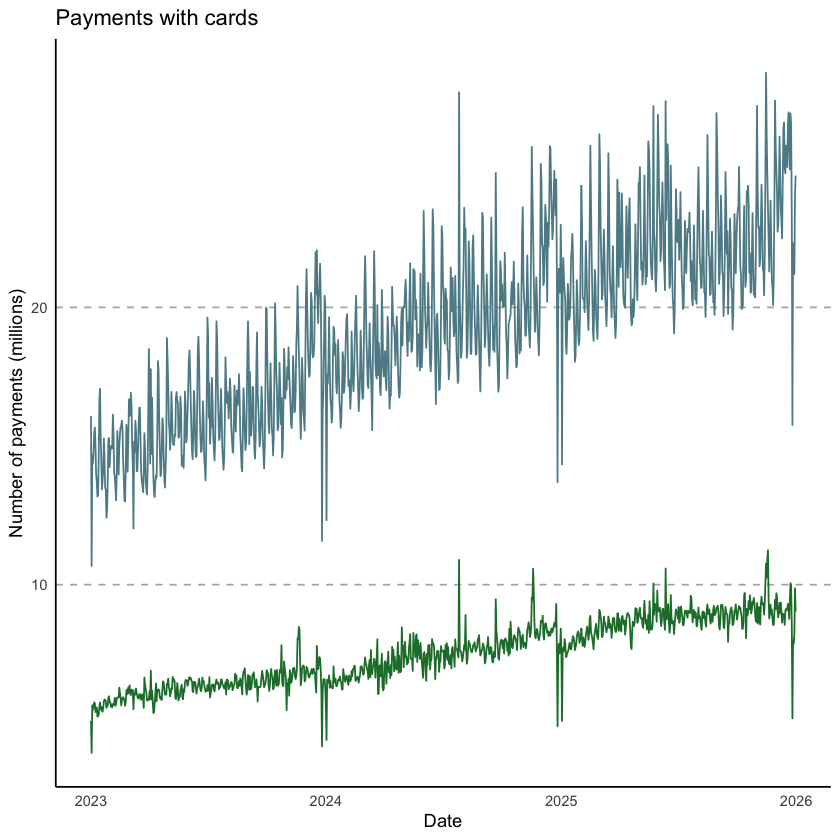

In [18]:
ggplot(data = df_ops, aes(x=date, y = debit)) +
    geom_line(color="#5d8b96") +
    geom_line(aes(x=date, y = credit), color="#1d7d36") + 
    theme_minimal() + 
    theme(
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_line(linetype="dashed", color = "gray70"),
        panel.grid.minor.y = element_blank(),
        axis.line = element_line(color="black")
    ) +
    labs(title = "Payments with cards",
        y = "Number of payments (millions)", 
        x= "Date"
        )

In [19]:
summary(df_ops)

      date                debit           credit      
 Min.   :2023-01-01   Min.   :10.68   Min.   : 3.937  
 1st Qu.:2023-10-01   1st Qu.:16.83   1st Qu.: 6.503  
 Median :2024-07-01   Median :19.35   Median : 7.521  
 Mean   :2024-07-01   Mean   :19.25   Mean   : 7.518  
 3rd Qu.:2025-04-01   3rd Qu.:21.40   3rd Qu.: 8.532  
 Max.   :2025-12-31   Max.   :28.46   Max.   :11.242  

The series shows a clear weekly seasonal pattern — operations tend to drop on mondays and tuesday and peak on friday and saturday — alongside a mild upward trend. Before applying smoothing techniques, it is useful to inspect the autocorrelation structure to confirm these patterns.

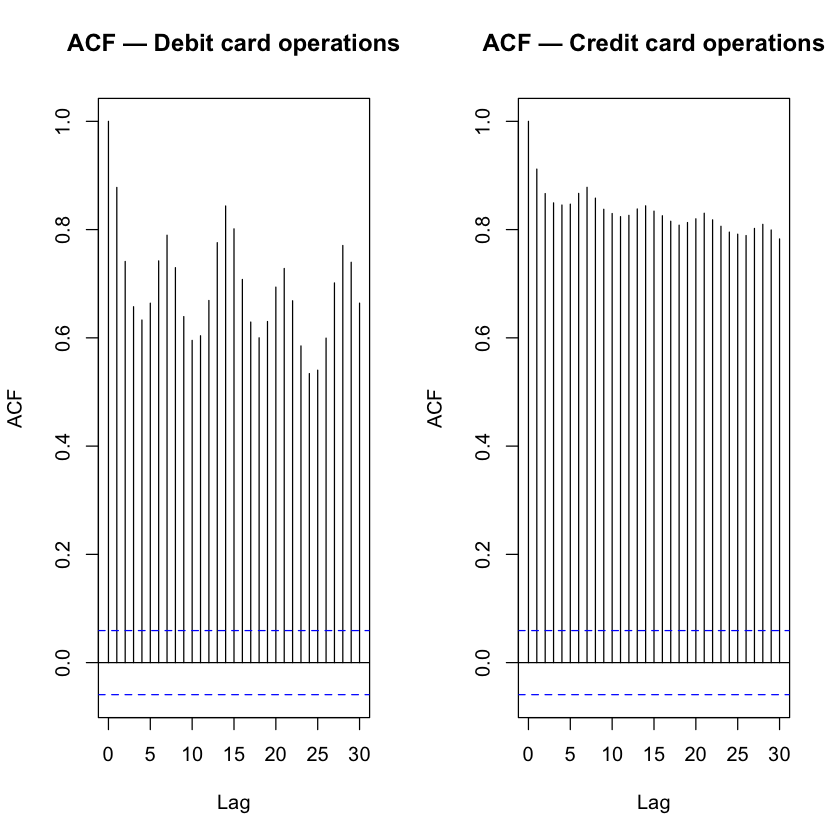

In [20]:
par(mfrow = c(1, 2))
acf(df_ops$debit,  lag.max = 30, main = "ACF — Debit card operations")
acf(df_ops$credit, lag.max = 30, main = "ACF — Credit card operations")
par(mfrow = c(1, 1))

The ACF plots confirm strong periodicity at lag 7 and its multiples, consistent with the weekly seasonality visible in the raw series. With this structure in mind, we now apply each smoothing method.

## 3. Moving Average

The simplest approach is the **moving average (MA)**, which replaces each observation with the arithmetic mean of a surrounding window of observations. Given the weekly cycle, we use a window of 7 days so that each day of the week contributes equally and the seasonal pattern is averaged out.

$$
\hat{y}_t = \frac{1}{2k+1} \sum_{j=-k}^{k} y_{t+j}
$$

where $k = 3$ for a 7-day centered window.

A larger window produces a smoother series but introduces more lag and loses observations at the boundaries.

Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 27 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 27 rows containing missing values or values outside the scale range
(`geom_line()`).”


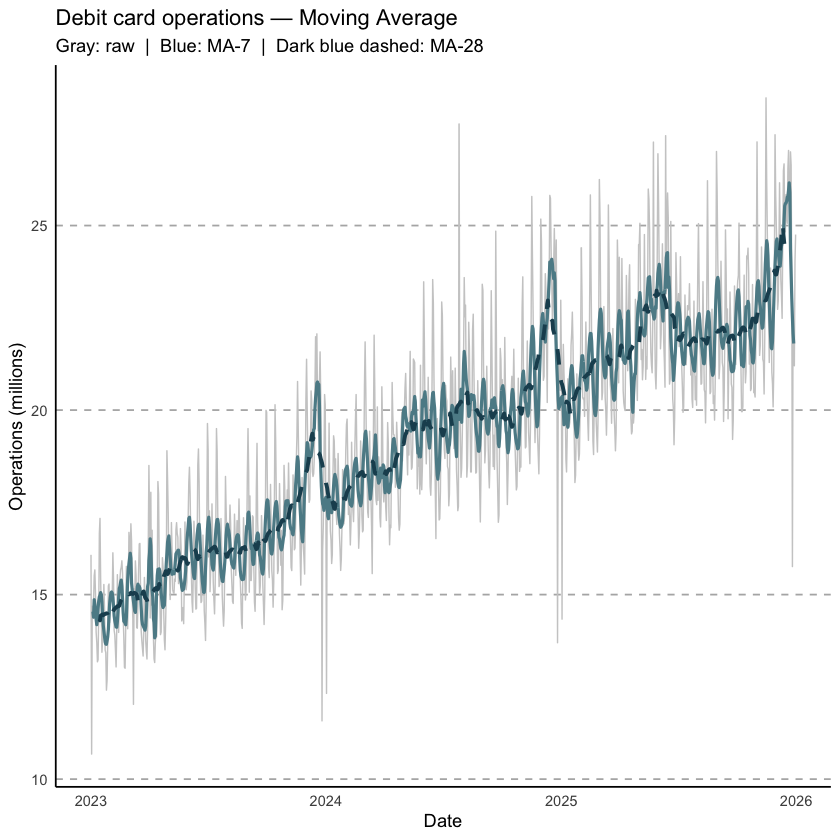

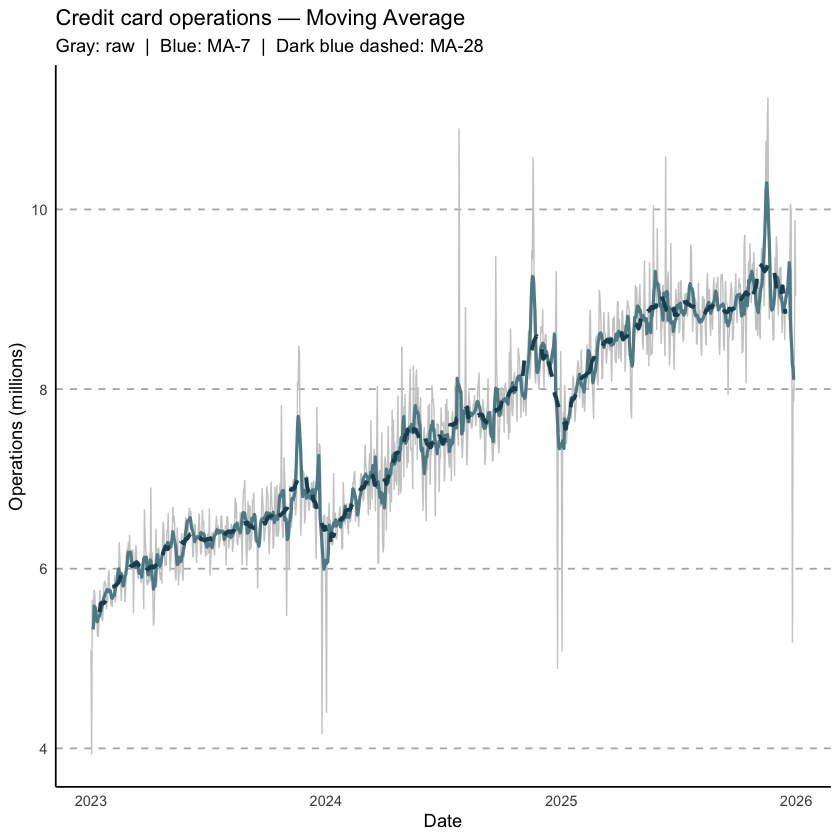

In [21]:
window_size <- 7

df_ma <- df_ops |>
    mutate(
        debit_ma7  = rollmean(debit,  k = window_size, fill = NA, align = "center"),
        credit_ma7 = rollmean(credit, k = window_size, fill = NA, align = "center"),
        debit_ma28  = rollmean(debit,  k = 28, fill = NA, align = "center"),
        credit_ma28 = rollmean(credit, k = 28, fill = NA, align = "center")
    )

plot_ma <- function(df, col_raw, col_ma7, col_ma28, title_txt) {
    ggplot(df, aes(x = date)) +
        geom_line(aes(y = .data[[col_raw]]),  color = "gray80", linewidth = 0.4) +
        geom_line(aes(y = .data[[col_ma7]]),  color = "#5d8b96", linewidth = 0.9) +
        geom_line(aes(y = .data[[col_ma28]]), color = "#1d4e5f", linewidth = 1.1, linetype = "dashed") +
        theme_minimal() +
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(linetype = "dashed", color = "gray70"),
            panel.grid.minor.y = element_blank(),
            axis.line = element_line(color = "black")
        ) +
        labs(
            title = title_txt,
            subtitle = "Gray: raw  |  Blue: MA-7  |  Dark blue dashed: MA-28",
            y = "Operations (millions)",
            x = "Date"
        )
}

plot_ma(df_ma, "debit",  "debit_ma7",  "debit_ma28",  "Debit card operations — Moving Average")
plot_ma(df_ma, "credit", "credit_ma7", "credit_ma28", "Credit card operations — Moving Average")

The MA-7 effectively removes the weekly pattern, revealing the underlying level of activity. The MA-28 goes further, filtering out shorter-term oscillations to show the monthly trend.

## 4. Exponential Smoothing

While the moving average weights all observations in the window equally, **exponential smoothing** assigns exponentially decreasing weights to past observations, giving more importance to recent values. The basic (simple) form is:

$$
\hat{y}_{t+1} = \alpha \, y_t + (1 - \alpha) \, \hat{y}_t, \quad \alpha \in (0, 1)
$$

Because our series has both trend and seasonality, we use **Holt-Winters triple exponential smoothing**, which adds equations for the trend ($\beta$) and seasonal ($\gamma$) components. R's `HoltWinters()` function estimates all three smoothing parameters by minimising the one-step-ahead forecast errors.

In [22]:
# Convert to ts objects with weekly frequency
ts_debit  <- ts(df_ops$debit,  frequency = 7)
ts_credit <- ts(df_ops$credit, frequency = 7)

# Fit Holt-Winters with additive seasonality
hw_debit  <- HoltWinters(ts_debit,  seasonal = "additive")
hw_credit <- HoltWinters(ts_credit, seasonal = "additive")

cat("Debit  — alpha:", round(hw_debit$alpha, 3),
    " beta:", round(hw_debit$beta, 3),
    " gamma:", round(hw_debit$gamma, 3), "\n")
cat("Credit — alpha:", round(hw_credit$alpha, 3),
    " beta:", round(hw_credit$beta, 3),
    " gamma:", round(hw_credit$gamma, 3), "\n")

Debit  — alpha: 0.778  beta: 0.001  gamma: 0.191 
Credit — alpha: 0.205  beta: 0.001  gamma: 0.076 


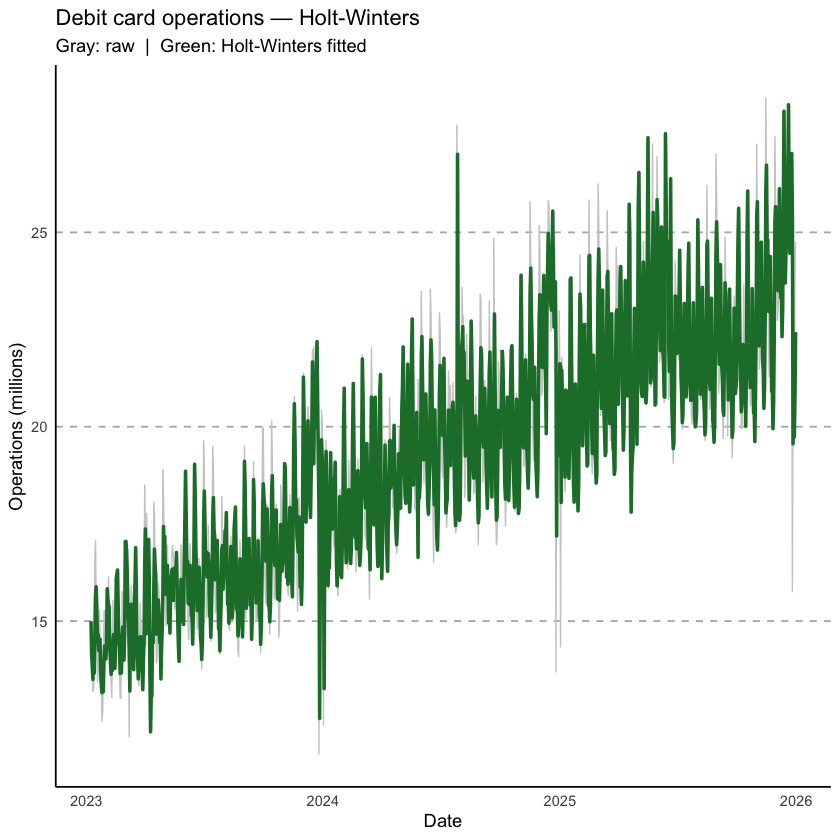

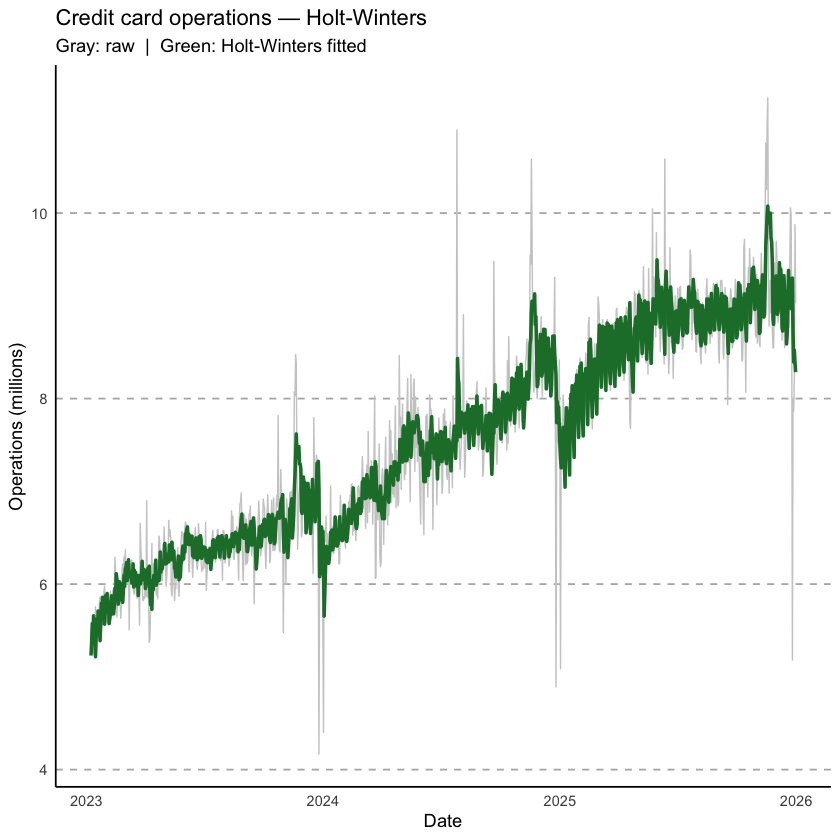

In [23]:
plot_hw <- function(ts_raw, hw_model, title_txt) {
    fitted_vals <- hw_model$fitted[, "xhat"]
    n_fitted    <- length(fitted_vals)
    n_raw       <- length(ts_raw)
    dates_fitted <- df_ops$date[(n_raw - n_fitted + 1):n_raw]

    df_hw <- data.frame(
        date    = dates_fitted,
        raw     = as.numeric(ts_raw[(n_raw - n_fitted + 1):n_raw]),
        fitted  = as.numeric(fitted_vals)
    )

    ggplot(df_hw, aes(x = date)) +
        geom_line(aes(y = raw),    color = "gray80", linewidth = 0.4) +
        geom_line(aes(y = fitted), color = "#1d7d36", linewidth = 1.0) +
        theme_minimal() +
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(linetype = "dashed", color = "gray70"),
            panel.grid.minor.y = element_blank(),
            axis.line = element_line(color = "black")
        ) +
        labs(
            title    = title_txt,
            subtitle = "Gray: raw  |  Green: Holt-Winters fitted",
            y = "Operations (millions)",
            x = "Date"
        )
}

plot_hw(ts_debit,  hw_debit,  "Debit card operations — Holt-Winters")
plot_hw(ts_credit, hw_credit, "Credit card operations — Holt-Winters")

Holt-Winters captures both the upward trend and the weekly seasonality, producing a smoother fitted curve that tracks the data more closely than a simple moving average while adapting to structural level changes over time.

## 5. Seasonal-Trend Decomposition using LOESS (STL)

**STL** decomposes the series into three additive components:

$$
y_t = T_t + S_t + R_t
$$

where $T_t$ is the trend, $S_t$ is the seasonal component, and $R_t$ is the remainder (noise). The decomposition is performed iteratively using **LOESS** (Locally Estimated Scatterplot Smoothing), a non-parametric regression that fits local polynomial models. The key advantage of STL over classical decomposition is its robustness to outliers and its ability to handle changing seasonal patterns.

Key parameters:
- `s.window`: controls how rapidly the seasonal component can change (set to `"periodic"` for a constant seasonal pattern, or an odd integer for a time-varying one).
- `t.window`: controls the smoothness of the trend.

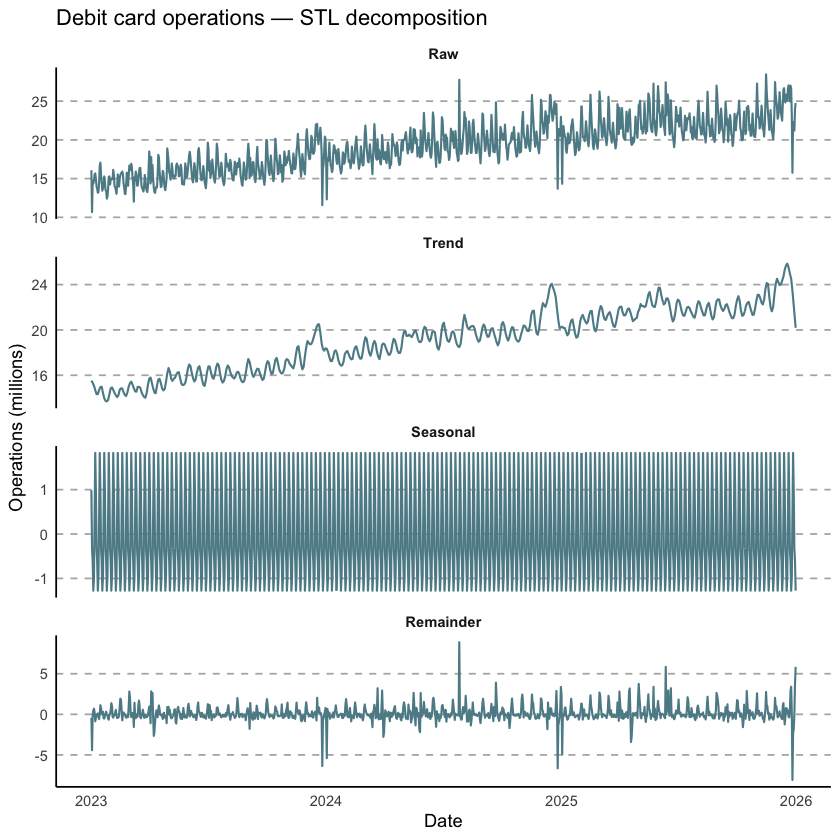

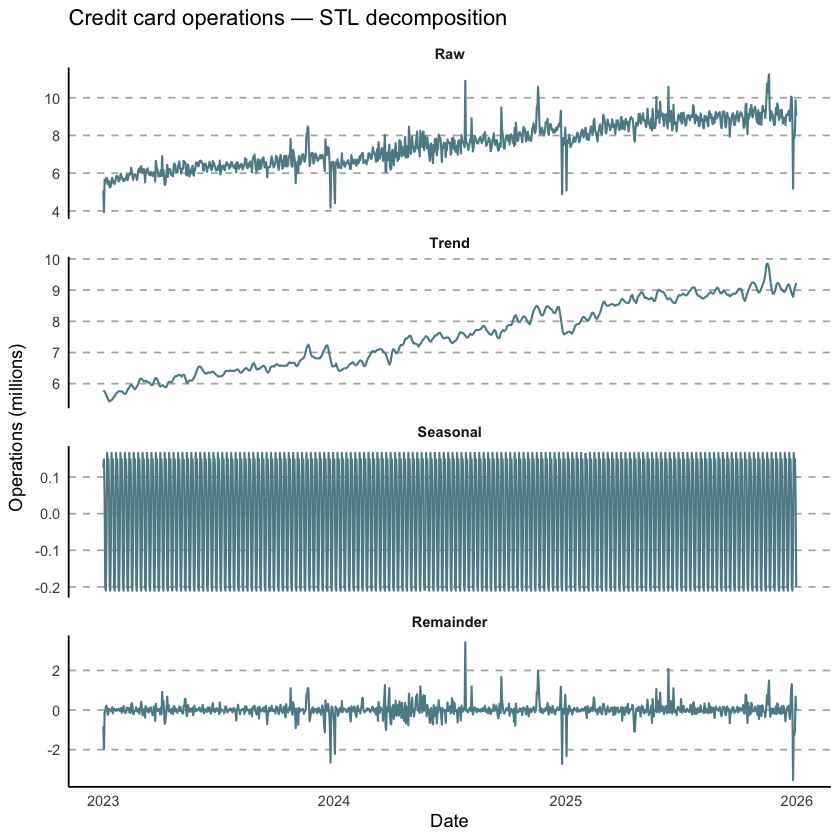

In [24]:
stl_debit  <- stl(ts_debit,  s.window = "periodic", robust = TRUE)
stl_credit <- stl(ts_credit, s.window = "periodic", robust = TRUE)

plot_stl <- function(stl_obj, dates, title_txt) {
    comps <- as.data.frame(stl_obj$time.series)
    comps$date    <- dates
    comps$raw     <- comps$trend + comps$seasonal + comps$remainder

    df_long <- comps |>
        pivot_longer(cols = c(raw, trend, seasonal, remainder),
                     names_to  = "component",
                     values_to = "value") |>
        mutate(component = factor(component,
                                  levels = c("raw", "trend", "seasonal", "remainder"),
                                  labels = c("Raw", "Trend", "Seasonal", "Remainder")))

    ggplot(df_long, aes(x = date, y = value)) +
        geom_line(color = "#5d8b96", linewidth = 0.6) +
        facet_wrap(~ component, ncol = 1, scales = "free_y") +
        theme_minimal() +
        theme(
            strip.text = element_text(face = "bold"),
            panel.grid.major.x = element_blank(),
            panel.grid.minor   = element_blank(),
            panel.grid.major.y = element_line(linetype = "dashed", color = "gray70"),
            axis.line = element_line(color = "black")
        ) +
        labs(title = title_txt, y = "Operations (millions)", x = "Date")
}

plot_stl(stl_debit,  df_ops$date, "Debit card operations — STL decomposition")
plot_stl(stl_credit, df_ops$date, "Credit card operations — STL decomposition")

STL separates the series into interpretable components. The **trend** panel shows the underlying growth trajectory with no seasonal noise. The **seasonal** panel reveals the stable weekly pattern (e.g. lower volumes on weekends). The **remainder** captures anomalies and irregular fluctuations — short spikes here may correspond to holidays or exceptional events.

## 6. Dynamic Linear Model (DLM)

The **Dynamic Linear Model** (also called State-Space Model or Kalman filter model) offers the most flexible probabilistic framework. Unlike the previous methods, it models the series as an observation of a latent state that evolves over time:

$$
\begin{aligned}
y_t &= F_t \theta_t + \nu_t, \quad \nu_t \sim \mathcal{N}(0, V) & \text{(observation equation)} \\
\theta_t &= G_t \theta_{t-1} + \omega_t, \quad \omega_t \sim \mathcal{N}(0, W) & \text{(state equation)}
\end{aligned}
$$

where $\theta_t$ is the latent state vector (level + trend + seasonal harmonics), and $V$, $W$ are the observation and evolution variances respectively. The **Kalman filter** recursively updates the state estimate as new data arrive.

We use the `dlm` package. Our model includes:
- A **local linear trend** (level + slope)
- A **periodic seasonal** component with period 7, modelled via trigonometric harmonics (3 harmonic pairs)

In [25]:
# Build a DLM with local linear trend + weekly trigonometric seasonality
build_dlm <- function(par) {
    dlmModPoly(order = 2, dV = exp(par[1]), dW = exp(par[2:3])) +
    dlmModTrig(s = 7,    dV = 0,           dW = exp(par[4]))
}

# Maximum-likelihood estimation of variances for debit
fit_debit  <- dlmMLE(ts_debit,  parm = rep(0, 4), build = build_dlm, hessian = FALSE)
fit_credit <- dlmMLE(ts_credit, parm = rep(0, 4), build = build_dlm, hessian = FALSE)

cat("Debit  converged:", fit_debit$convergence  == 0, "\n")
cat("Credit converged:", fit_credit$convergence == 0, "\n")

Debit  converged: TRUE 
Credit converged: TRUE 


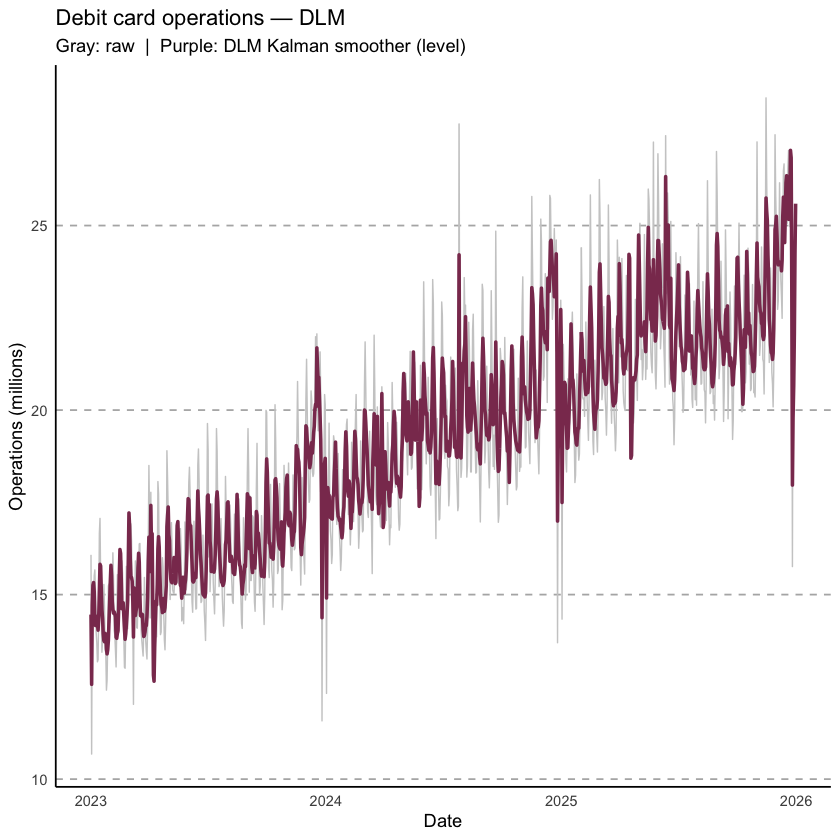

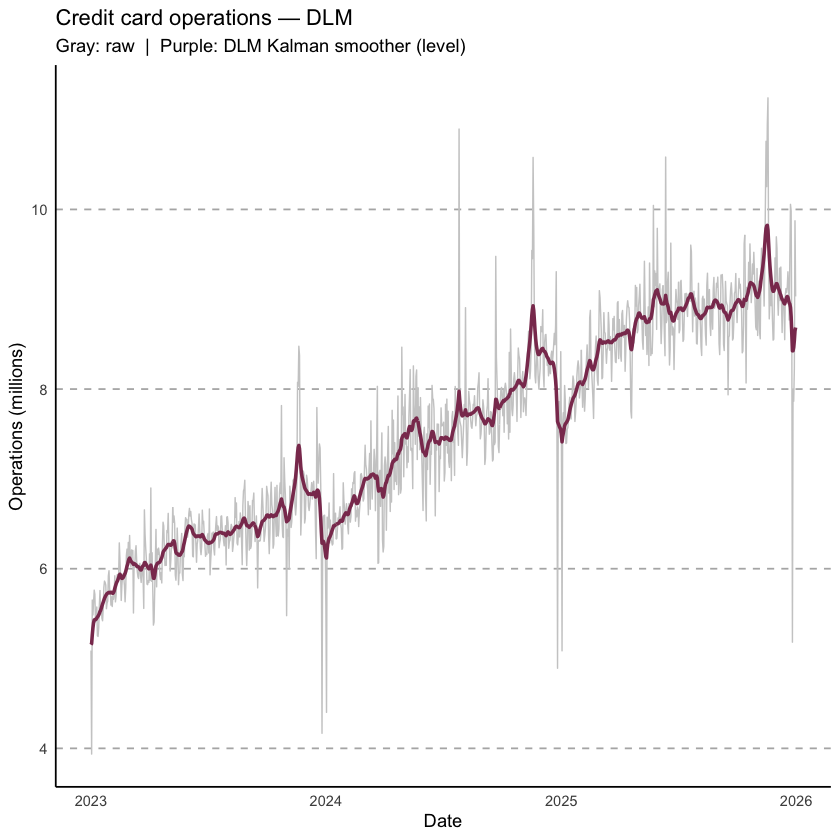

In [26]:
# Run Kalman smoother to obtain posterior state estimates
mod_debit  <- build_dlm(fit_debit$par)
mod_credit <- build_dlm(fit_credit$par)

smooth_debit  <- dlmSmooth(ts_debit,  mod_debit)
smooth_credit <- dlmSmooth(ts_credit, mod_credit)

# Extract the smoothed level (first state component)
dlm_level_debit  <- dropFirst(smooth_debit$s[, 1])
dlm_level_credit <- dropFirst(smooth_credit$s[, 1])

plot_dlm <- function(raw_ts, smoothed_level, dates, title_txt) {
    df_dlm <- data.frame(
        date    = dates,
        raw     = as.numeric(raw_ts),
        smoothed = smoothed_level
    )

    ggplot(df_dlm, aes(x = date)) +
        geom_line(aes(y = raw),      color = "gray80",   linewidth = 0.4) +
        geom_line(aes(y = smoothed), color = "#8b3a5d",  linewidth = 1.0) +
        theme_minimal() +
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(linetype = "dashed", color = "gray70"),
            panel.grid.minor.y = element_blank(),
            axis.line = element_line(color = "black")
        ) +
        labs(
            title    = title_txt,
            subtitle = "Gray: raw  |  Purple: DLM Kalman smoother (level)",
            y = "Operations (millions)",
            x = "Date"
        )
}

plot_dlm(ts_debit,  dlm_level_debit,  df_ops$date, "Debit card operations — DLM")
plot_dlm(ts_credit, dlm_level_credit, df_ops$date, "Credit card operations — DLM")

The DLM smoother produces the most adaptive trend estimate: because it uses the full dataset in a backward pass (Kalman smoother, as opposed to the forward-only Kalman filter), it incorporates future information to refine past state estimates. This results in a very smooth level trajectory with no boundary issues.

## 7. Methods comparison

It is useful to overlay all four smoothed signals on the same plot to compare their characteristics.

Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_line()`).”


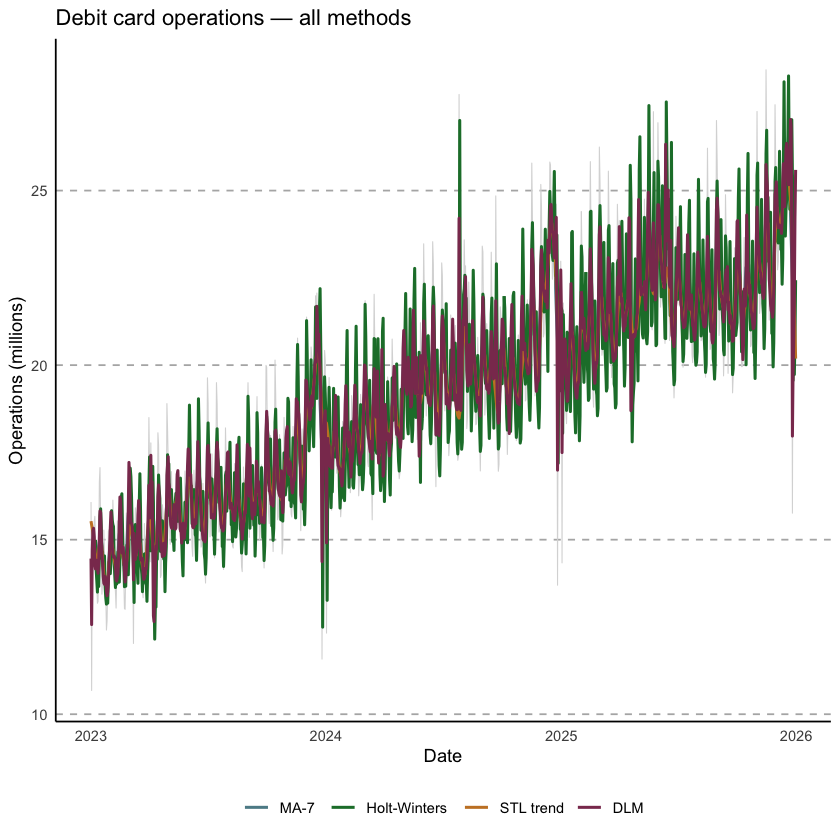

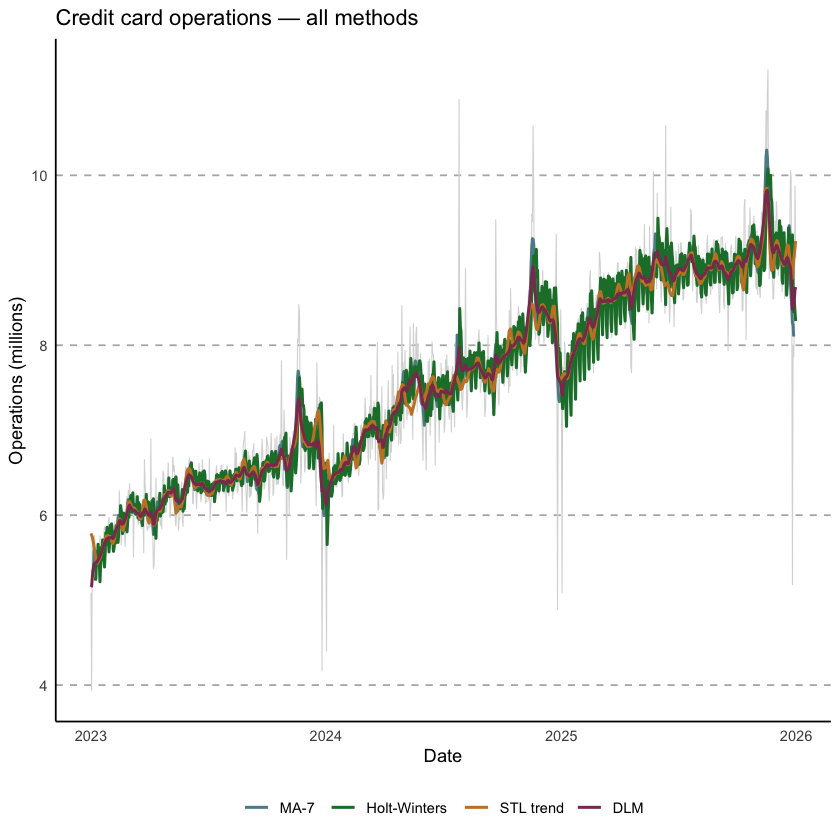

In [27]:
compare_methods <- function(series_name) {
    is_debit <- series_name == "debit"
    raw_vec  <- if (is_debit) df_ops$debit   else df_ops$credit
    n        <- length(raw_vec)

    # MA-7
    ma7  <- as.numeric(rollmean(raw_vec, k = 7, fill = NA, align = "center"))

    # Holt-Winters fitted
    hw_obj    <- if (is_debit) hw_debit  else hw_credit
    hw_fitted <- as.numeric(hw_obj$fitted[, "xhat"])
    hw_padded <- c(rep(NA, n - length(hw_fitted)), hw_fitted)

    # STL trend
    stl_obj   <- if (is_debit) stl_debit  else stl_credit
    stl_trend <- as.numeric(stl_obj$time.series[, "trend"])

    # DLM level
    dlm_level <- if (is_debit) dlm_level_debit else dlm_level_credit

    df_cmp <- data.frame(
        date       = df_ops$date,
        raw        = raw_vec,
        ma7        = ma7,
        holt_winters = hw_padded,
        stl_trend  = stl_trend,
        dlm        = as.numeric(dlm_level)
    ) |>
    pivot_longer(cols = -date, names_to = "method", values_to = "value") |>
    mutate(method = factor(method,
                           levels = c("raw", "ma7", "holt_winters", "stl_trend", "dlm"),
                           labels = c("Raw", "MA-7", "Holt-Winters", "STL trend", "DLM")))

    colours <- c("Raw"         = "gray80",
                 "MA-7"        = "#5d8b96",
                 "Holt-Winters"= "#1d7d36",
                 "STL trend"   = "#c8822e",
                 "DLM"         = "#8b3a5d")

    sizes <- c("Raw"=0.35, "MA-7"=0.85, "Holt-Winters"=0.85, "STL trend"=0.85, "DLM"=0.85)

    title_txt <- if (is_debit) "Debit card operations" else "Credit card operations"

    ggplot(df_cmp |> filter(method != "Raw"), aes(x = date, y = value, color = method, linewidth = method)) +
        geom_line(data = df_cmp |> filter(method == "Raw"),
                  aes(x = date, y = value), color = "gray85", linewidth = 0.3, inherit.aes = FALSE) +
        geom_line() +
        scale_color_manual(values = colours) +
        scale_linewidth_manual(values = sizes) +
        theme_minimal() +
        theme(
            panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.y = element_line(linetype = "dashed", color = "gray70"),
            panel.grid.minor.y = element_blank(),
            axis.line          = element_line(color = "black"),
            legend.title       = element_blank(),
            legend.position    = "bottom"
        ) +
        labs(
            title = paste(title_txt, "— all methods"),
            y     = "Operations (millions)",
            x     = "Date"
        )
}

compare_methods("debit")
compare_methods("credit")

## 8. Conclusions

The four methods converge on a consistent picture of the series but differ in trade-offs:

| Method | Strengths | Limitations |
|---|---|---|
| **Moving Average** | Simple, interpretable, no model assumptions | Loses observations at boundaries; all lags equally weighted |
| **Holt-Winters** | Handles trend + seasonality; adapts to level changes | Requires stationarity of seasonal amplitude; can overfit |
| **STL** | Robust to outliers; decomposes into interpretable components; flexible seasonal window | Does not produce probability intervals by default |
| **DLM** | Full probabilistic framework; online updating via Kalman filter; can produce credible intervals | More complex to specify and estimate; computationally intensive |

For monitoring card payment trends at Banco de México, the **STL trend** and **DLM level** are the most suitable: STL provides clean decomposition for reporting, while DLM is preferable when probabilistic uncertainty quantification or real-time sequential updating is needed.

Both debit and credit card operations show a consistent **upward trend** over the 2023–2025 period, with a stable weekly seasonal pattern (lower on weekends) and no structural breaks in the remainder components.